# Import packages

In [2]:
import tifffile
from tifffile import TiffWriter, TiffReader

In [ ]:
%%time
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import os
import scipy

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['pdf.fonttype'] = 42   
plt.rcParams["font.sans-serif"] ='Arial' 

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

CPU times: user 3.56 s, sys: 1.92 s, total: 5.48 s
Wall time: 33.2 s


In [4]:
import xml.etree.ElementTree as ET

# Settings

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import sys

sys.path.append('/mIF_TMA_analysis/')

from src.plot import  plot_roi
from src.plot.plot_roi import plot_roi_cell, plot_roi_region

In [7]:
sc.set_figure_params(dpi=100, figsize=(4, 4), dpi_save=500)

In [8]:
def add_rectangle(
    ax,
    crop_para
):
    '''xxx'''
    x, y, width, height = crop_para
    
    rect = plt.Rectangle((x, y), width, height, fill=False, edgecolor='red', linewidth=1)
    ax.add_patch(rect)

In [9]:
def plot_spatial(
    adata,
    sample,
    **kwargs
):
    '''xxx'''
    _ = sc.pl.embedding(adata[adata.obs['sample'].isin([sample])], basis='spatial', show=False, **kwargs)

    if not isinstance(_, list):
        _ = [_]
    
    for i in _:
        i.invert_yaxis()

# Read in data

In [ ]:
ct2col = plot_roi.default_cell_type_color()

celltype_colors = {
    "CD8 T":         "#0077B6",
    "PD1+ CD8 T":  "#48CAE4",

    "CD4 T":         "#C68A00",
    "CXCL13+ CD4 T": "#FFD166",

    "B cell":            "#B5179E",
    "CXCR5+ B":     "#E76BF3",
    "IgG PC":       "#FF6D00",

    "CXCL12+ Fibro":"#C44536",
    "Macrophage":   "#6FAF9F",

    "Epithelium": "#aec7e8"
}

ct2col.update(celltype_colors)

## 231107

In [ ]:
sample = '231107'
adata = sc.read_h5ad(f'/data/{sample}/adata_{sample}_analysed.h5ad')
cell_mask = tifffile.imread(f'/data/cell_mask.tif')
boundary_mask = tifffile.imread(f'/data/boundary_mask.tif')
tiff = TiffReader(f'/ome_tiff/protein_stain_{sample}.ome.tif')

In [12]:
img = tiff.asarray()

In [13]:
metadata = tiff.ome_metadata  ## 
img.shape
root = ET.fromstring(metadata)
namespace = {'ome':'http://www.openmicroscopy.org/Schemas/OME/2016-06'}
channel_names = []
for channel in root.findall('.//ome:Channel', namespace):
    name = channel.get('Name')
    channel_names.append(name)

- signal

In [14]:
crop_para = [10900, 2220, 1400, 1400]

(8, 1400, 1400)


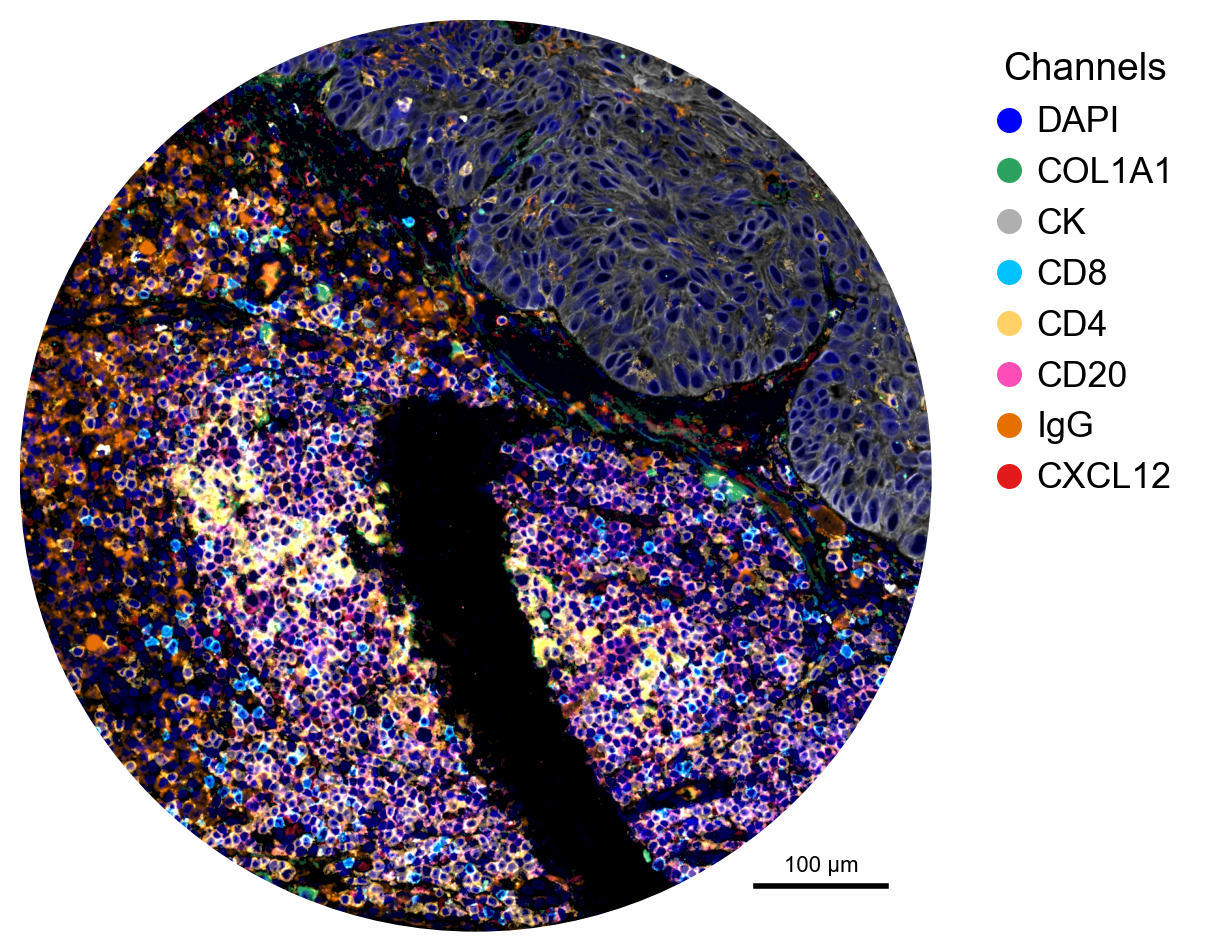

In [ ]:
### zoom-in
colors = { 
     "DAPI":   "#0000FF",
   "COL1A1":  "#2CA25F",  # 
    "CK": "#AFAFAF",  # 
    "CD8":    "#00C2FF",  # 
    "CD4":    "#FFD166",  # 
    "CD20":   "#FF4DB8",  # 
    "IgG":    "#E76F00",  # 
    "CXCL12": "#E31A1C",  #
         }

vmax = {
    'DAPI': 220,
    'COL1A1': 90,
    'CK': 100,
    'CD8': 55,
    'CD4': 70,
    'CD20': 220,
    'IgG': 180,
    'CXCL12': 70
}

vmin = {
    'DAPI': 8,
    'COL1A1': 8,
    'CK': 8,
    'CD8': 6,
    'CD4': 12,
    'CD20': 15,
    'IgG': 15,
    'CXCL12': 8
}

raw_channel_order = channel_names

plot_roi.plot_roi_signal_with_legend(
    img, 
    cell_mask=cell_mask,
    crop_para=crop_para,
    channels_color=colors,
    channel_order=raw_channel_order,
    vmin=vmin,
    vmax=vmax,
    bbox_to_anchor=(1.3, 1),
    scale_bar_um=100,
    clip_circle=True,
)

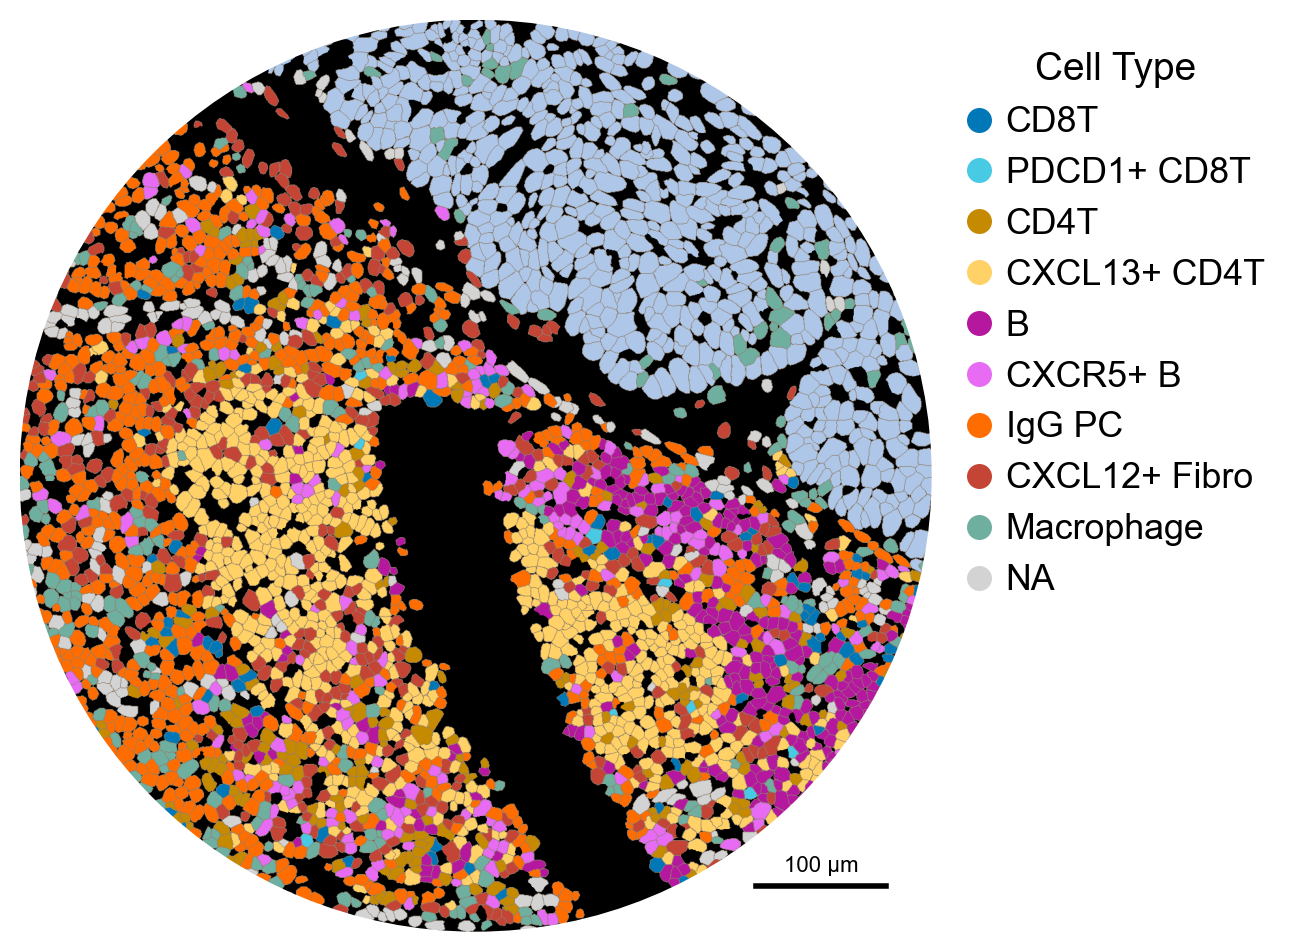

In [ ]:
cellid2celltype_dict = plot_roi.get_cellid_to_celltype(adata, crop_para=crop_para, celltype_key='celltype')

plot_roi.plot_roi_mask_with_legend(cell_mask, boundary_mask, crop_para=crop_para, cellid2celltype=cellid2celltype_dict, 
                          groups=[ 'CD8 T', 'PDCD1+ CD8 T', 'CD4 T', 'CXCL13+ CD4 T', 'B', 'CXCR5+ B', 'IgG PC', 'CXCL12+ Fibro','Macrophage'], 
                                   ct2col=ct2col,
                                   scale_bar_um=100,
                                   show_legend=True,
                                   clip_circle=True,
                                   bbox_to_anchor=(1.4, 1),
                                  )